In [1]:
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
sc.set_figure_params(figsize=(8, 8))

Global seed set to 0


## tried different ways of integration
Train model, batch = origin, covariate = stage & sample, origin split extended

comes out on top

In [2]:
# load Chim data
adata_chim = sc.read_h5ad('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/processed/anndata.h5ad')
chim_meta = adata_chim.obs.loc[:,['sample', 'stage']]
chim_meta['origin'] = 'Chimera'
adata_chim.obs = chim_meta

# load Atlas data
adata_atlas = sc.read_h5ad('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/extended/processed/anndata.h5ad')
atlas_meta = adata_atlas.obs.iloc[:,0:2]
atlas_meta['origin'] = 'Atlas'
adata_atlas.obs = atlas_meta

In [5]:
adata_full = ad.concat([adata_chim, adata_atlas], join="inner")

In [6]:
# preprocessing
sc.pp.filter_genes(adata_full, min_counts=3)
adata_full.layers["counts"] = adata_full.X.copy() # preserve counts
adata_full.raw = adata_full # freeze the state in `.raw`

sc.pp.highly_variable_genes(
    adata_full,
    n_top_genes=3000,
    subset=True,
    layer="counts",
    flavor="cell_ranger",
    batch_key="stage"
)

/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'stage' as categorical
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'origin' as categorical
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a

### Train model, batch = stage, covariate = origin

In [52]:
scvi.model.SCVI.setup_anndata(
    adata_full,
    layer="counts",
    batch_key="stage",
    categorical_covariate_keys=["origin"]
)

INFO     Using batches from adata.obs["stage"]                                               
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 161229 cells, 3000 vars, 13       
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


In [54]:
model = scvi.model.SCVI(adata_full, n_latent=50)

In [55]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 50/50: 100%|██████████| 50/50 [1:05:12<00:00, 78.25s/it, loss=1.7e+03, v_num=1] 


In [56]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_model/")

In [58]:
latent = model.get_latent_representation()
adata_full.obsm["X_scVI"] = latent

In [62]:
latent = pd.DataFrame(adata_full.obsm['X_scVI'])
latent.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_latent_dims.csv")

In [63]:
meta = pd.DataFrame(adata_full.obs)
meta.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_meta.csv")

### Train model, batch = origin, covariate = stage

In [64]:
scvi.model.SCVI.setup_anndata(
    adata_full,
    layer="counts",
    batch_key="origin",
    categorical_covariate_keys=["stage"]
)

INFO     Using batches from adata.obs["origin"]                                              
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 161229 cells, 3000 vars, 2        
         batches, 1 labels, and 0 proteins. Also registered 1 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


In [65]:
model = scvi.model.SCVI(adata_full, n_latent=50)

In [66]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 50/50: 100%|██████████| 50/50 [1:11:46<00:00, 86.13s/it, loss=1.69e+03, v_num=1]


In [67]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_model_origin/")

In [68]:
latent = model.get_latent_representation()
adata_full.obsm["X_scVI"] = latent

In [69]:
latent = pd.DataFrame(adata_full.obsm['X_scVI'])
latent.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_latent_dims_origin.csv")

In [70]:
meta = pd.DataFrame(adata_full.obs)
meta.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_meta_origin.csv")

### Train model, batch = origin, covariate = stage & sample

In [72]:
scvi.model.SCVI.setup_anndata(
    adata_full,
    layer="counts",
    batch_key="origin",
    categorical_covariate_keys=["stage", "sample"]
)

INFO     Using batches from adata.obs["origin"]                                              
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 161229 cells, 3000 vars, 2        
         batches, 1 labels, and 0 proteins. Also registered 2 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


In [73]:
model = scvi.model.SCVI(adata_full, n_latent=50)

In [74]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 50/50: 100%|██████████| 50/50 [1:11:03<00:00, 85.28s/it, loss=1.7e+03, v_num=1] 


In [75]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_model_origin_sample/")

In [77]:
latent = model.get_latent_representation()
adata_full.obsm["X_scVI"] = latent

In [76]:
latent = pd.DataFrame(adata_full.obsm['X_scVI'])
latent.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_latent_dims_origin_sample.csv")

In [78]:
meta = pd.DataFrame(adata_full.obs)
meta.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_meta_origin_sample.csv")

### Train model, batch = origin, covariate = stage & sample, origin split extended

In [7]:
import re

In [8]:
full_meta = adata_full.obs

In [76]:
vec = list(full_meta.origin)
for i in  range(full_meta.shape[0]):
    if full_meta.index[i].startswith('ext'):
        vec[i] = 'Ext'


In [80]:
full_meta.origin = vec

In [85]:
full_meta.origin.value_counts()

Atlas      68489
Ext        47070
Chimera    45670
Name: origin, dtype: int64

In [86]:
adata_full.obs = full_meta

In [88]:
scvi.model.SCVI.setup_anndata(
    adata_full,
    layer="counts",
    batch_key="origin",
    categorical_covariate_keys=["stage", "sample"]
)

INFO     Using batches from adata.obs["origin"]                                              
INFO     No label_key inputted, assuming all cells have same label                           
INFO     Using data from adata.layers["counts"]                                              
INFO     Successfully registered anndata object containing 161229 cells, 3000 vars, 3        
         batches, 1 labels, and 0 proteins. Also registered 2 extra categorical covariates   
         and 0 extra continuous covariates.                                                  
INFO     Please do not further modify adata until model is trained.                          


In [89]:
model = scvi.model.SCVI(adata_full, n_latent=50)

In [90]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 50/50: 100%|██████████| 50/50 [1:00:50<00:00, 73.00s/it, loss=1.68e+03, v_num=1]


In [91]:
model.save("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_model_origin_sample_ext/")

In [92]:
latent = model.get_latent_representation()
adata_full.obsm["X_scVI"] = latent

In [93]:
latent = pd.DataFrame(adata_full.obsm['X_scVI'])
latent.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_latent_dims_origin_sample_ext.csv")

In [94]:
meta = pd.DataFrame(adata_full.obs)
meta.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/full_meta_origin_sample_ext.csv")

# Mapping on atlas - not ideal bc model includes the query data

In [118]:
# load Chim data
adata_chim = sc.read_h5ad('/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/processed/anndata.h5ad')
chim_meta = adata_chim.obs.loc[:,['sample', 'stage']]
chim_meta['origin'] = 'Chimera'
adata_chim.obs = chim_meta

In [119]:
# preprocessing
sc.pp.filter_genes(adata_chim, min_counts=0)
adata_chim.layers["counts"] = adata_chim.X.copy() # preserve counts
adata_chim.raw = adata_chim # freeze the state in `.raw`

In [120]:
adata_chim = adata_chim[:, adata_full.var.index]

In [121]:
vae_q = scvi.model.SCVI.load_query_data(
    adata_chim,
    model,
)

/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/model/base/_archesmixin.py:95: UserWarning: Query integration should be performed using models trained with version >= 0.8
  warnings.warn(
/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function transfer_anndata_setup is deprecated; This method will be removed in 0.15.0. Please avoid building any new dependencies on it.
  warnings.warn(msg, category=FutureWarning)
Trying to set attribute `._uns` of view, copying.


INFO     .obs[_scvi_labels] not found in target, assuming every cell is same category        
INFO     Using data from adata.layers["counts"]                                              
INFO     Registered keys:['X', 'batch_indices', 'labels', 'cat_covs']                        
INFO     Successfully registered anndata object containing 45670 cells, 3000 vars, 3 batches,
         1 labels, and 0 proteins. Also registered 2 extra categorical covariates and 0 extra
         continuous covariates.                                                              


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/scvi/data/_anndata.py:315: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [123]:
vae_q.train(max_epochs=100, plan_kwargs=dict(weight_decay=0.0))
adata_chim.obsm["X_scVI"] = vae_q.get_latent_representation()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
Set SLURM handle signals.


Epoch 100/100: 100%|██████████| 100/100 [59:25<00:00, 35.66s/it, loss=2.1e+03, v_num=1]


In [125]:
sc.pp.neighbors(adata_chim, use_rep="X_scVI")
sc.tl.umap(adata_chim)

Epoch 2/200:   0%|          | 1/200 [1:19:28<263:36:52, 4768.91s/it, loss=2.2e+03, v_num=1]


/home/bt392/miniconda3/envs/env_scvi2/lib/python3.9/site-packages/anndata/_core/anndata.py:1228: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  c.reorder_categories(natsorted(c.categories), inplace=True)
... storing 'origin' as categorical


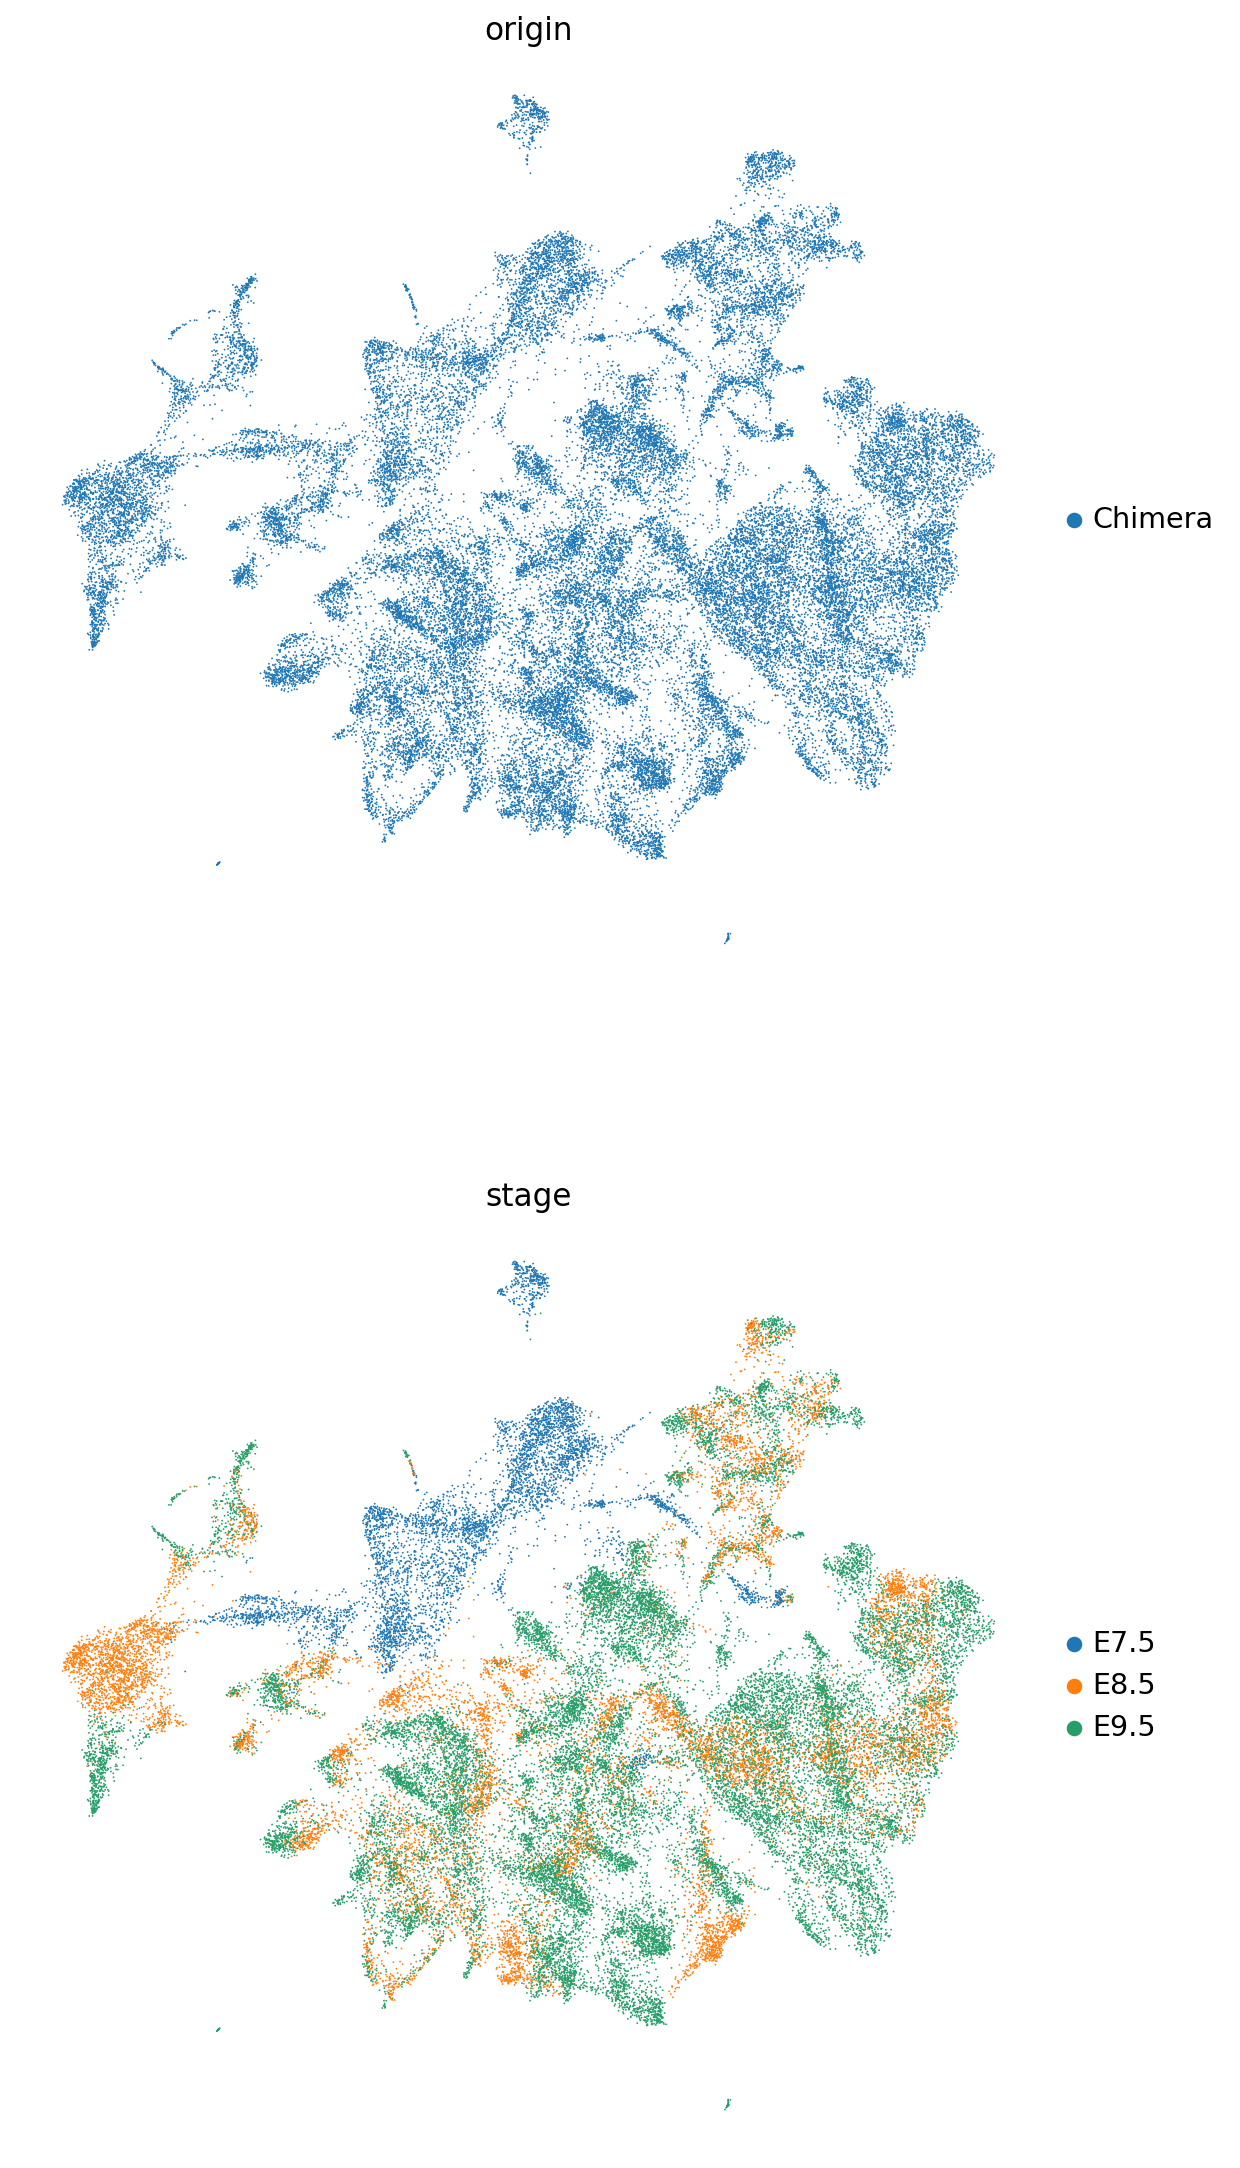

In [127]:
sc.pl.umap(
    adata_chim,
    color=["origin", "stage"],
    frameon=False,
    ncols=1,
)

In [129]:
latent = pd.DataFrame(adata_chim.obsm['X_scVI'])
latent.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/query_stat3.csv")

meta = pd.DataFrame(adata_chim.obs)
meta.to_csv("/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/results/rna/scvi/query_stat3_meta.csv")